# Perturbed Kerr Geodesics — EMRI Numerical Integration

Numerical integration of Kerr geodesics under first- and second-order
Hamiltonian perturbations (H₁, H₂), approximated by holding the unperturbed
equations of motion fixed and substituting a time-varying Carter constant
K(λ). Developed for EMRI (Extreme Mass Ratio Inspiral) research under
Dr. Sajal Mukherjee, BITS Pilani.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import sympy as sp
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter, find_peaks
from scipy.interpolate import UnivariateSpline, CubicSpline
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from IPython.display import display, Markdown

def make_smooth_K(lam_data, k_values, window=51, poly=3, spline_smooth=1e-4):
    """
    Returns a smoothed callable K(lambda).

    Parameters
    ----------
    lam_data : 1-D array  – affine parameter samples from DATA_CARTER.dat
    k_values : 1-D array  – Carter constant samples
    window   : int        – Savitzky-Golay window length (must be odd, > poly)
    poly     : int        – SG polynomial order
    spline_smooth : float – UnivariateSpline smoothing factor for the residual
    """
    window = window if window % 2 == 1 else window + 1
    k_sg = savgol_filter(k_values, window_length=window, polyorder=poly)
    return UnivariateSpline(lam_data, k_sg, s=spline_smooth, ext='const')

data_carter = np.loadtxt('DATA_CARTER.dat')
lam_data_carter = data_carter[:, 0]
k_values = data_carter[:, 1]
get_K = make_smooth_K(lam_data_carter, k_values, window=51, poly=3)

print(f"Carter constant data spans λ ∈ [0, {lam_data_carter[-1]:.1f}]")

Carter constant data spans λ ∈ [0, 1010.0]


In [2]:
print(k_values[0])

9.511042091238595


K smoothing residual: mean=-2.776e-11, max=6.229e-05, std=9.969e-06


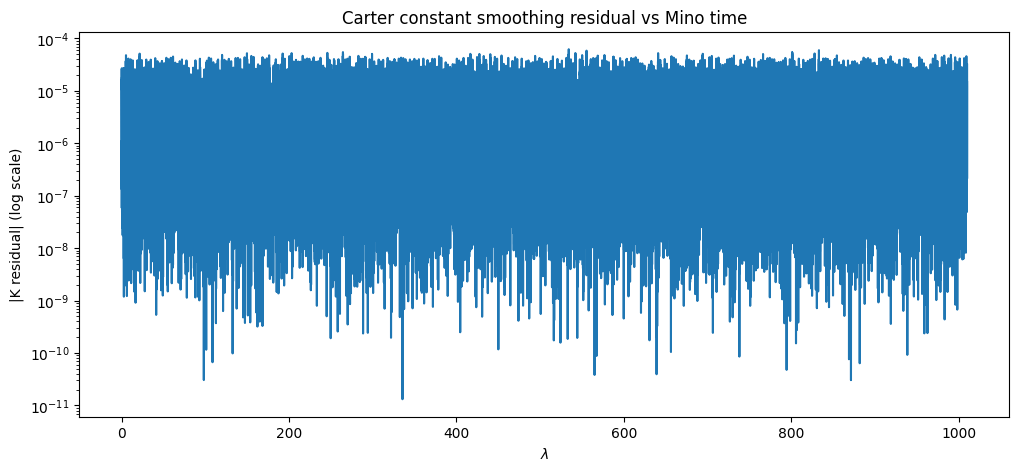

Max residual at λ=534.099 (data range ends at 1010.0)
Residuals > 1e-6: 884491 / 1009999 points


In [3]:
K_residual = get_K(lam_data_carter) - k_values
print(f"K smoothing residual: mean={np.mean(K_residual):.3e}, "
      f"max={np.max(np.abs(K_residual)):.3e}, std={np.std(K_residual):.3e}")

plt.figure(figsize=(12, 5))
plt.semilogy(lam_data_carter, np.abs(K_residual))
plt.xlabel(r'$\lambda$'); plt.ylabel('|K residual| (log scale)')
plt.title('Carter constant smoothing residual vs Mino time')
plt.show()

# is the max an isolated edge artifact, or spread through the trajectory?
worst_idx = np.argmax(np.abs(K_residual))
print(f"Max residual at λ={lam_data_carter[worst_idx]:.3f} (data range ends at {lam_data_carter[-1]:.1f})")
print(f"Residuals > 1e-6: {np.sum(np.abs(K_residual) > 1e-6)} / {len(K_residual)} points")

## 2. Symbolic potentials

The effective potentials V₁(r), V₂(θ) below are what the integrator actually
uses — derived here symbolically and compiled via `lambdify` for speed.

In [4]:
r, theta, E, Lz, a, epsilon, kappa = sp.symbols('r theta E L_z a epsilon kappa')
M = 1.0

Delta_s, Sigma_s, H1_s, H2_s = sp.symbols('Delta Sigma H_1 H_2')

Delta_math = r**2 - 2*M*r + a**2
Sigma_math = r**2 + a**2 * sp.cos(theta)**2
H1_math = epsilon * (Lz - 2*a*E)
H2_math = (epsilon**2 / (8*Sigma_s)) * (
    -4*a**2*Delta_s
    + (5*a**4 + r**4 + 2*a**2*r**2 - 8*M*a**2*r) * sp.sin(theta)**2
    - a**2 * Delta_s * sp.sin(theta)**4
)

V1_disp = (E*(r**2 + a**2) - a*Lz)**2 - Delta_s*(kappa + r**2) + Delta_s*r**2*H1_s - 2*Delta_s*r**2*H2_s
V2_disp = (1/sp.sin(theta)**2) * (
    (kappa - (Lz - a*E)**2) * sp.sin(theta)**2
    - (Lz*sp.cos(theta))**2
    + (a*E*sp.cos(theta)*sp.sin(theta))**2
    - (a*sp.cos(theta)*sp.sin(theta))**2
    - (a*sp.cos(theta)*sp.sin(theta))**2 * H1_s
    - 2*(a*sp.cos(theta)*sp.sin(theta))**2 * H2_s
)

H2_full = H2_math.subs({Delta_s: Delta_math, Sigma_s: Sigma_math})
V1_full = V1_disp.subs({Delta_s: Delta_math, H1_s: H1_math, H2_s: H2_full})
V2_full = V2_disp.subs({H1_s: H1_math, H2_s: H2_full})

rhs_potentials = sp.lambdify((r, theta, E, Lz, a, kappa, epsilon), [V1_full, V2_full], 'numpy')

display(Markdown("### Symbolic Definitions"))
for label, expr in [("V_1", V1_disp), ("V_2", V2_disp), ("H_1", H1_math),
                     ("H_2", H2_math), ("\\Delta", Delta_math), ("\\Sigma", Sigma_math)]:
    display(Markdown(f"$$\\Large {sp.latex(sp.Eq(sp.Symbol(label), expr))}$$"))

### Symbolic Definitions

$$\Large V_{1} = \Delta H_{1} r^{2} - 2 \Delta H_{2} r^{2} - \Delta \left(\kappa + r^{2}\right) + \left(E \left(a^{2} + r^{2}\right) - L_{z} a\right)^{2}$$

$$\Large V_{2} = \frac{E^{2} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - H_{1} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - 2 H_{2} a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} - L_{z}^{2} \cos^{2}{\left(\theta \right)} - a^{2} \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} + \left(\kappa - \left(- E a + L_{z}\right)^{2}\right) \sin^{2}{\left(\theta \right)}}{\sin^{2}{\left(\theta \right)}}$$

$$\Large H_{1} = \epsilon \left(- 2 E a + L_{z}\right)$$

$$\Large H_{2} = \frac{\epsilon^{2} \left(- \Delta a^{2} \sin^{4}{\left(\theta \right)} - 4 \Delta a^{2} + \left(5 a^{4} + 2 a^{2} r^{2} - 8.0 a^{2} r + r^{4}\right) \sin^{2}{\left(\theta \right)}\right)}{8 \Sigma}$$

$$\Large \Delta = a^{2} + r^{2} - 2.0 r$$

$$\Large \Sigma = a^{2} \cos^{2}{\left(\theta \right)} + r^{2}$$

## 3. Verification: independent derivation from the metric

The potentials above are used for integration. As a cross-check, this section
re-derives the Hamiltonian H = ½(H₀ + H₁ + H₂) independently from the Kerr
metric components. `calc_H` (defined here) is reused later for the
Hamiltonian-conservation diagnostic.

In [5]:
r_v, theta_v, E_v, Lz_v, a_v, M_v, Pr_v, Pth_v, eps_v = sp.symbols(
    'r theta E L_z a M P_r P_theta epsilon'
)
Delta_abs, Sigma_abs = sp.symbols('Delta Sigma')

Delta_math_v = r_v**2 - 2*M_v*r_v + a_v**2
Sigma_math_v = r_v**2 + a_v**2*sp.cos(theta_v)**2

T_tt = -(r_v**2 + a_v**2)**2 / Delta_abs
T_tphi = -a_v*(r_v**2 + a_v**2) / Delta_abs
T_phiphi = -a_v**2 / Delta_abs
T_rr = Delta_abs

Theta_tt = a_v**2 * sp.sin(theta_v)**2
Theta_tphi = a_v
Theta_phiphi = 1 / sp.sin(theta_v)**2
Theta_thth = 1

H0_r = T_rr*Pr_v**2 + T_tt*E_v**2 - 2*T_tphi*E_v*Lz_v + T_phiphi*Lz_v**2
H0_th = Theta_thth*Pth_v**2 + Theta_tt*E_v**2 - 2*Theta_tphi*E_v*Lz_v + Theta_phiphi*Lz_v**2
H0 = (H0_r + H0_th) / Sigma_abs

H1 = eps_v * (Lz_v - 2*a_v*E_v)
H2 = (eps_v**2 / (8*Sigma_abs)) * (
    -4*a_v**2*Delta_abs
    + (5*a_v**4 + r_v**4 + 2*a_v**2*r_v**2 - 8*M_v*a_v**2*r_v) * sp.sin(theta_v)**2
    - a_v**2*Delta_abs*sp.sin(theta_v)**4
)
H_total = sp.Rational(1, 2) * (H0 + H1 + H2)
H_full_numeric = H_total.subs({Delta_abs: Delta_math_v, Sigma_abs: Sigma_math_v})

def show_eq(name, expr):
    display(Markdown(f"$$\\Large {sp.latex(sp.Eq(sp.Symbol(name), expr))}$$"))

display(Markdown("### Unperturbed Hamiltonian ($H_0$)"))
show_eq("H_0^r", sp.simplify(H0_r))
show_eq("H_0^theta", sp.simplify(H0_th))
show_eq("H_0", H0)

display(Markdown("### Perturbations ($H_1, H_2$)"))
show_eq("H_1", H1)
show_eq("H_2", H2)

display(Markdown("### Total Hamiltonian ($H$)"))
show_eq("H", H_total)

calc_H = sp.lambdify((r_v, theta_v, Pr_v, Pth_v, E_v, Lz_v, a_v, M_v, eps_v),
                      H_full_numeric, 'numpy')

### Unperturbed Hamiltonian ($H_0$)

$$\Large H^{r}_{0} = \frac{\Delta^{2} P_{r}^{2} - E^{2} \left(a^{2} + r^{2}\right)^{2} + 2 E L_{z} a \left(a^{2} + r^{2}\right) - L_{z}^{2} a^{2}}{\Delta}$$

$$\Large H^{\theta}_{0} = E^{2} a^{2} \sin^{2}{\left(\theta \right)} - 2 E L_{z} a + \frac{L_{z}^{2}}{\sin^{2}{\left(\theta \right)}} + P_{\theta}^{2}$$

$$\Large H_{0} = \frac{\Delta P_{r}^{2} + E^{2} a^{2} \sin^{2}{\left(\theta \right)} - 2 E L_{z} a + \frac{L_{z}^{2}}{\sin^{2}{\left(\theta \right)}} + P_{\theta}^{2} - \frac{E^{2} \left(a^{2} + r^{2}\right)^{2}}{\Delta} + \frac{2 E L_{z} a \left(a^{2} + r^{2}\right)}{\Delta} - \frac{L_{z}^{2} a^{2}}{\Delta}}{\Sigma}$$

### Perturbations ($H_1, H_2$)

$$\Large H_{1} = \epsilon \left(- 2 E a + L_{z}\right)$$

$$\Large H_{2} = \frac{\epsilon^{2} \left(- \Delta a^{2} \sin^{4}{\left(\theta \right)} - 4 \Delta a^{2} + \left(- 8 M a^{2} r + 5 a^{4} + 2 a^{2} r^{2} + r^{4}\right) \sin^{2}{\left(\theta \right)}\right)}{8 \Sigma}$$

### Total Hamiltonian ($H$)

$$\Large H = \frac{\epsilon \left(- 2 E a + L_{z}\right)}{2} + \frac{\epsilon^{2} \left(- \Delta a^{2} \sin^{4}{\left(\theta \right)} - 4 \Delta a^{2} + \left(- 8 M a^{2} r + 5 a^{4} + 2 a^{2} r^{2} + r^{4}\right) \sin^{2}{\left(\theta \right)}\right)}{16 \Sigma} + \frac{\Delta P_{r}^{2} + E^{2} a^{2} \sin^{2}{\left(\theta \right)} - 2 E L_{z} a + \frac{L_{z}^{2}}{\sin^{2}{\left(\theta \right)}} + P_{\theta}^{2} - \frac{E^{2} \left(a^{2} + r^{2}\right)^{2}}{\Delta} + \frac{2 E L_{z} a \left(a^{2} + r^{2}\right)}{\Delta} - \frac{L_{z}^{2} a^{2}}{\Delta}}{2 \Sigma}$$

In [6]:
# Sanity check: V1 from §2 matches the independent derivation at a test point
E_val, Lz_val, a_val, eps_val = 0.98, 3.3, 0.5, -0.001
lam_test, r_test, th_test = 2.642455, 40.324777, 1.572211
test_state = (r_test, th_test, E_val, Lz_val, a_val, get_K(lam_test), eps_val)
v1_test = rhs_potentials(*test_state)[0]
print(f"V1 at test state: {v1_test}")

V1 at test state: 0.5573385981842875


## 4. Integrator

DOP853 integration with a proxy-jump event scheme: the solver halts just
before each turning point (where √V → 0 breaks the Lipschitz condition
required by adaptive-step solvers), flips the sign of the corresponding
velocity, and restarts.

For λ beyond `learning_threshold`, jump sizes are extrapolated from a linear
fit to previously observed jumps rather than recomputed from scratch — a
cost-saving measure for long integrations. It does not activate for the
λ range presented in this notebook's results, but is left in for future
extended runs.

`get_K` is passed explicitly (not read from the global scope) so that
alternate K(λ) functions — e.g. the perturbed one used in §7 — can't
silently leak into other cells.

In [7]:
def geodesic_integrator(initial_state, initial_signs, lam_range, params,
                         epsilon, proxy_eps, proxy_eps_th, rtol, atol,
                         K_func, learning_threshold=150.0):
    E_val, Lz_val, a_val = params
    curr_lam, end_lam = lam_range
    curr_state = np.array(initial_state, dtype=float)

    def odes(t, y, E_v, Lz_v, a_v, eps_v):
        r_c, th_c = y
        k_c = K_func(t)
        v1, v2 = rhs_potentials(r_c, th_c, E_v, Lz_v, a_v, k_c, eps_v)
        dr = np.sqrt(np.maximum(v1, proxy_eps)) * odes.sign_r
        dt = np.sqrt(np.maximum(v2, proxy_eps_th)) * odes.sign_th
        return [dr, dt]
    odes.sign_r, odes.sign_th = initial_signs

    def local_slope_r(r_val, th_val, E_v, Lz_v, a_v, k_v, eps_v, h=1e-6):
        v1_plus, _  = rhs_potentials(r_val + h, th_val, E_v, Lz_v, a_v, k_v, eps_v)
        v1_minus, _ = rhs_potentials(r_val - h, th_val, E_v, Lz_v, a_v, k_v, eps_v)
        return (v1_plus - v1_minus) / (2 * h)

    def local_slope_th(r_val, th_val, E_v, Lz_v, a_v, k_v, eps_v, h=1e-6):
        _, v2_plus  = rhs_potentials(r_val, th_val + h, E_v, Lz_v, a_v, k_v, eps_v)
        _, v2_minus = rhs_potentials(r_val, th_val - h, E_v, Lz_v, a_v, k_v, eps_v)
        return (v2_plus - v2_minus) / (2 * h)

    def event_v1(t, y, *args):
        v1, _ = rhs_potentials(y[0], y[1], *args[:3], K_func(t), args[3])
        return v1 - proxy_eps
    event_v1.terminal, event_v1.direction = True, -1

    def event_v2(t, y, *args):
        _, v2 = rhs_potentials(y[0], y[1], *args[:3], K_func(t), args[3])
        return v2 - proxy_eps_th
    event_v2.terminal, event_v2.direction = True, -1

    def event_horizon(t, y, *args): return y[0] - 2.001
    event_horizon.terminal = True

    def event_r_max(t, y, *args): return y[0] - 100.0
    event_r_max.terminal = True

    def event_theta_bounds(t, y, *args):
        return (y[1] - 0.001) * (np.pi - 0.001 - y[1])
    event_theta_bounds.terminal = True

    all_r, all_th, all_l, all_vr, all_vth = [], [], [], [], []
    loop_log = []

    data_lam_r_in, data_dt_r_in = [], []
    data_lam_r_out, data_dt_r_out = [], []
    data_lam_th, data_dt_th = [], []
    models_fitted = False
    fit_r_in = fit_r_out = fit_th = None

    while curr_lam < end_lam:
        sol = solve_ivp(
            odes, (curr_lam, end_lam), curr_state,
            args=(E_val, Lz_val, a_val, epsilon),
            events=[event_v1, event_v2, event_horizon, event_r_max, event_theta_bounds],
            rtol=rtol, atol=atol, method='DOP853', dense_output=True
        )

        r_seg, th_seg, t_seg = sol.y[0], sol.y[1], sol.t
        v1_seg, v2_seg = rhs_potentials(r_seg, th_seg, E_val, Lz_val, a_val,
                                         K_func(t_seg), epsilon)
        vr_seg = np.sqrt(np.maximum(v1_seg, proxy_eps)) * odes.sign_r
        vth_seg = np.sqrt(np.maximum(v2_seg, proxy_eps_th)) * odes.sign_th

        sl = slice(None) if not all_l else slice(1, None)
        all_r.extend(r_seg[sl]); all_th.extend(th_seg[sl]); all_l.extend(t_seg[sl])
        all_vr.extend(vr_seg[sl]); all_vth.extend(vth_seg[sl])

        curr_state = sol.y[:, -1]
        curr_lam = sol.t[-1]

        loop_log.append({
            'lambda': curr_lam, 'state': curr_state.tolist(),
            'events': [len(e) for e in sol.t_events],
            'simultaneous_rth_event': (sol.t_events[0].size > 0 and sol.t_events[1].size > 0),
            'success': sol.success, 'message': sol.message
        })

        if sol.t_events[2].size > 0:
            print(f"Halt: horizon reached at λ={curr_lam:.2f}"); break
        if sol.t_events[3].size > 0 or sol.t_events[4].size > 0:
            print(f"Halt: boundary reached at λ={curr_lam:.2f}"); break

        if curr_lam >= learning_threshold and not models_fitted:
            def safe_fit(lam_d, dt_d):
                if len(lam_d) > 1:
                    return np.poly1d(np.polyfit(lam_d, dt_d, 1))
                return np.poly1d([0, np.mean(dt_d) if dt_d else 1e-6])
            fit_r_in = safe_fit(data_lam_r_in, data_dt_r_in)
            fit_r_out = safe_fit(data_lam_r_out, data_dt_r_out)
            fit_th = safe_fit(data_lam_th, data_dt_th)
            models_fitted = True

        # -----------------------------------------
        # R-turning point logic
        # -----------------------------------------
        factor = 2
        r_jump_dt = None
        if sol.t_events[0].size > 0:
            is_inner = (odes.sign_r == -1)
            odes.sign_r *= -1

            # Slope-scaled nudge: near a simple zero, V(r) ≈ V'(r_tp)·(r−r_tp),
            # so proxy_eps/|V'| is the coordinate distance needed to clear the
            # threshold. Clipped to stay within a sane range of the old fixed value.
            k_now = K_func(curr_lam)
            dV1_dr = local_slope_r(curr_state[0], curr_state[1], E_val, Lz_val, a_val, k_now, epsilon)
            nudge_r = np.clip(factor * proxy_eps / abs(dV1_dr), max(1e-8, 10 * atol), 1e-8)
            '''print(f"λ={curr_lam:.3f}  |dV1/dr|={abs(dV1_dr):.3e}  nudge_r={nudge_r:.3e}  "
                  f"clipped={'YES' if nudge_r in (1e-10, 1e-6) else 'no'}")'''

            curr_state[0] += odes.sign_r * nudge_r

            if curr_lam < learning_threshold:
                if len(all_l) >= 2 and (all_r[-1] - all_r[-2]) != 0:
                    dyn_dt = np.abs((all_l[-1]-all_l[-2]) / (all_r[-1]-all_r[-2])) * 1e-8
                else:
                    dyn_dt = 1e-6
                (data_lam_r_in if is_inner else data_lam_r_out).append(curr_lam)
                (data_dt_r_in if is_inner else data_dt_r_out).append(dyn_dt)
                r_jump_dt = dyn_dt
            else:
                r_jump_dt = np.maximum(fit_r_in(curr_lam) if is_inner else fit_r_out(curr_lam), 1e-10)

        # -----------------------------------------
        # Theta-turning point logic
        # -----------------------------------------
        th_jump_dt = None
        if sol.t_events[1].size > 0:
            odes.sign_th *= -1

            k_now = K_func(curr_lam)
            dV2_dth = local_slope_th(curr_state[0], curr_state[1], E_val, Lz_val, a_val, k_now, epsilon)
            nudge_th = np.clip(factor * proxy_eps / abs(dV2_dth), max(1e-8, 10 * atol), 1e-8)
            curr_state[1] += odes.sign_th * nudge_th

            if curr_lam < learning_threshold:
                if len(all_l) >= 2 and (all_th[-1] - all_th[-2]) != 0:
                    dyn_dt = np.abs((all_l[-1]-all_l[-2]) / (all_th[-1]-all_th[-2])) * 1e-8
                else:
                    dyn_dt = 1e-6
                data_lam_th.append(curr_lam)
                data_dt_th.append(dyn_dt)
                th_jump_dt = dyn_dt
            else:
                th_jump_dt = np.maximum(fit_th(curr_lam), 1e-10)

        # -----------------------------------------
        # Advance lambda by the larger of the two jumps, if either fired
        # (guarantees both signs have flipped and both states nudged
        #  before the next solve_ivp call, even if both events fired together)
        # -----------------------------------------
        if r_jump_dt is not None or th_jump_dt is not None:
            curr_lam += max(filter(None, [r_jump_dt, th_jump_dt]))

    return {
        'r': np.array(all_r), 'theta': np.array(all_th), 'lambda': np.array(all_l),
        'vr': np.array(all_vr), 'vtheta': np.array(all_vth), 'log': pd.DataFrame(loop_log)
    }

## 5. Production run

In [8]:
init_state = [40.323, np.pi/2]     # (r_initial, theta_initial)
phys_params = (0.98, 3.3, 0.5)     # (E, Lz, a)
eps = -0.001
LAM_RANGE = [0, 450]
PROXY_EPS, PROXY_EPS_TH = 2.8e-9, 2.8e-9
RTOL, ATOL = 2.8e-9, 3.5e-10

results = geodesic_integrator(
    init_state, initial_signs=[-1, 1], lam_range=LAM_RANGE,
    params=phys_params, epsilon=eps,
    proxy_eps=PROXY_EPS, proxy_eps_th=PROXY_EPS_TH,
    rtol=RTOL, atol=ATOL, K_func=get_K
)

In [9]:
# Clean near-duplicate lambda entries (from event-driven restarts) and export
def clean_run(res, tol=1e-14):
    diffs = np.diff(res['lambda'])
    mask = np.append(diffs > tol, [True])
    return {k: (v[mask] if isinstance(v, np.ndarray) else v) for k, v in res.items()}

results_clean = clean_run(results)
df = pd.DataFrame({
    'lambda': results_clean['lambda'], 'r': results_clean['r'],
    'theta': results_clean['theta'], 'vr': results_clean['vr'],
    'vth': results_clean['vtheta']
})
df.to_csv('results/geodesic_trajectory.csv', index=False)
results['log'].to_csv('results/loop_log.csv', index=False)

## 6. Results

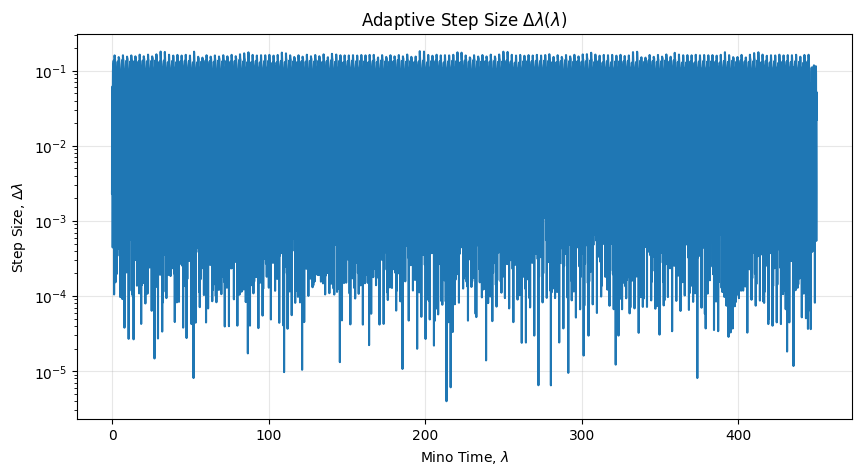

In [10]:
# Step size over the integration
delta_lam = np.diff(results['lambda'])
plt.figure(figsize=(10, 5))
plt.semilogy(results['lambda'][:-1], delta_lam)
plt.ylabel(r'Step Size, $\Delta\lambda$'); plt.xlabel(r'Mino Time, $\lambda$')
plt.title(r'Adaptive Step Size $\Delta\lambda(\lambda)$')
plt.grid(True, alpha=0.3)
plt.show()

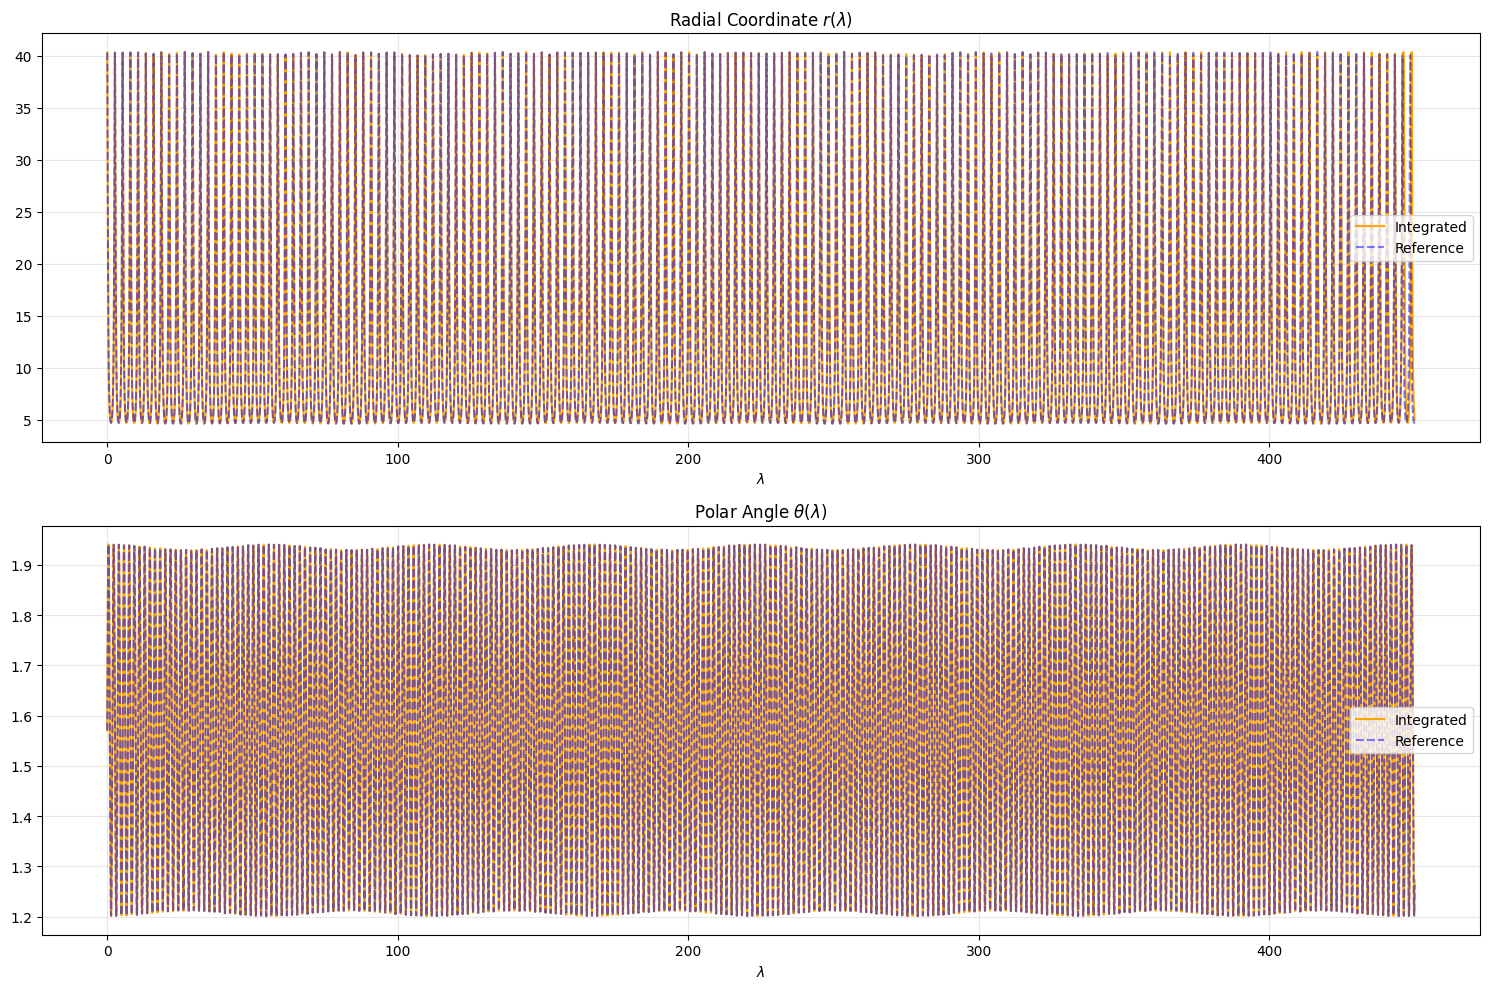

r:     mean error = 1.896e-02, max error = 2.696e+00
theta: mean error = 3.381e-03, max error = 1.046e-02


In [11]:
# Trajectory comparison against reference data
r_arr, th_arr, lam_arr = df['r'], df['theta'], df['lambda']
vth_arr, vr_arr = df['vth'], df['vr']
sigma_num = r_arr**2 + (a_val * np.cos(th_arr))**2
delta_num = r_arr**2 - 2.0*r_arr + a_val**2
pth_arr = vth_arr
pr_arr = (1/delta_num)*vr_arr

data_r_ext = np.loadtxt('reference_r.dat')       # was Neal_data.dat
data_th_ext = np.loadtxt('reference_th.dat')  # was theta.dat
lam_data_ext, r_ext = data_r_ext[:, 0], data_r_ext[:, 1]
th_ext = data_th_ext[:, 1]

lam_grid = np.linspace(0, lam_arr.to_numpy()[-1], 10000)
r_solved_grid = CubicSpline(lam_arr, r_arr)(lam_grid)
th_solved_grid = CubicSpline(lam_arr, th_arr)(lam_grid)
r_ext_grid = CubicSpline(lam_data_ext, r_ext)(lam_grid)
th_ext_grid = CubicSpline(lam_data_ext, th_ext)(lam_grid)

f, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
ax1.plot(lam_grid, r_solved_grid, color='orange', label='Integrated')
ax1.plot(lam_grid, r_ext_grid, '--', color='blue', alpha=0.5, label='Reference')
ax1.set_title(r"Radial Coordinate $r(\lambda)$"); ax1.set_xlabel(r"$\lambda$")
ax1.grid(alpha=0.3); ax1.legend()

ax2.plot(lam_grid, th_solved_grid, color='orange', label='Integrated')
ax2.plot(lam_grid, th_ext_grid, '--', color='blue', alpha=0.5, label='Reference')
ax2.set_title(r"Polar Angle $\theta(\lambda)$"); ax2.set_xlabel(r"$\lambda$")
ax2.grid(alpha=0.3); ax2.legend()
plt.tight_layout()
plt.savefig("results/trajectory_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

error_r = np.abs(r_solved_grid - r_ext_grid) / np.abs(r_ext_grid)
error_th = np.abs(th_solved_grid - th_ext_grid) / np.abs(th_ext_grid)
print(f"r:     mean error = {np.mean(error_r):.3e}, max error = {np.max(error_r):.3e}")
print(f"theta: mean error = {np.mean(error_th):.3e}, max error = {np.max(error_th):.3e}")

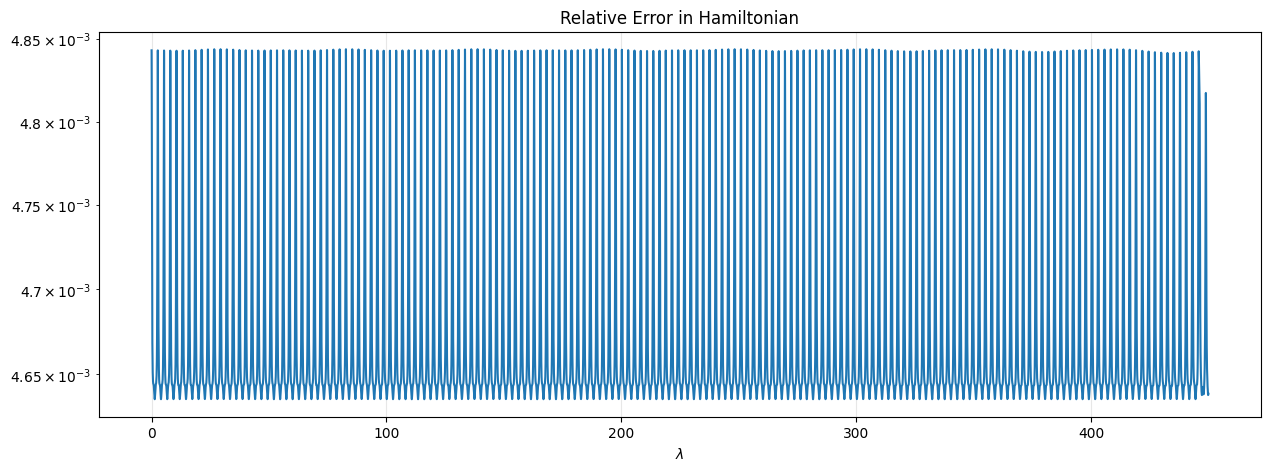

mean H error: 4.704e-03


In [12]:
# Hamiltonian conservation
H_arr = calc_H(r_arr, th_arr, pr_arr, pth_arr, *phys_params, 1.0, eps)
H_error = np.abs((H_arr + 0.5) / 0.5)

plt.figure(figsize=(15, 5))
plt.semilogy(lam_arr, H_error)
plt.title('Relative Error in Hamiltonian'); plt.xlabel(r'$\lambda$')
plt.grid(alpha=0.3)
plt.savefig("results/hamiltonian_error.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"mean H error: {np.mean(H_error):.3e}")

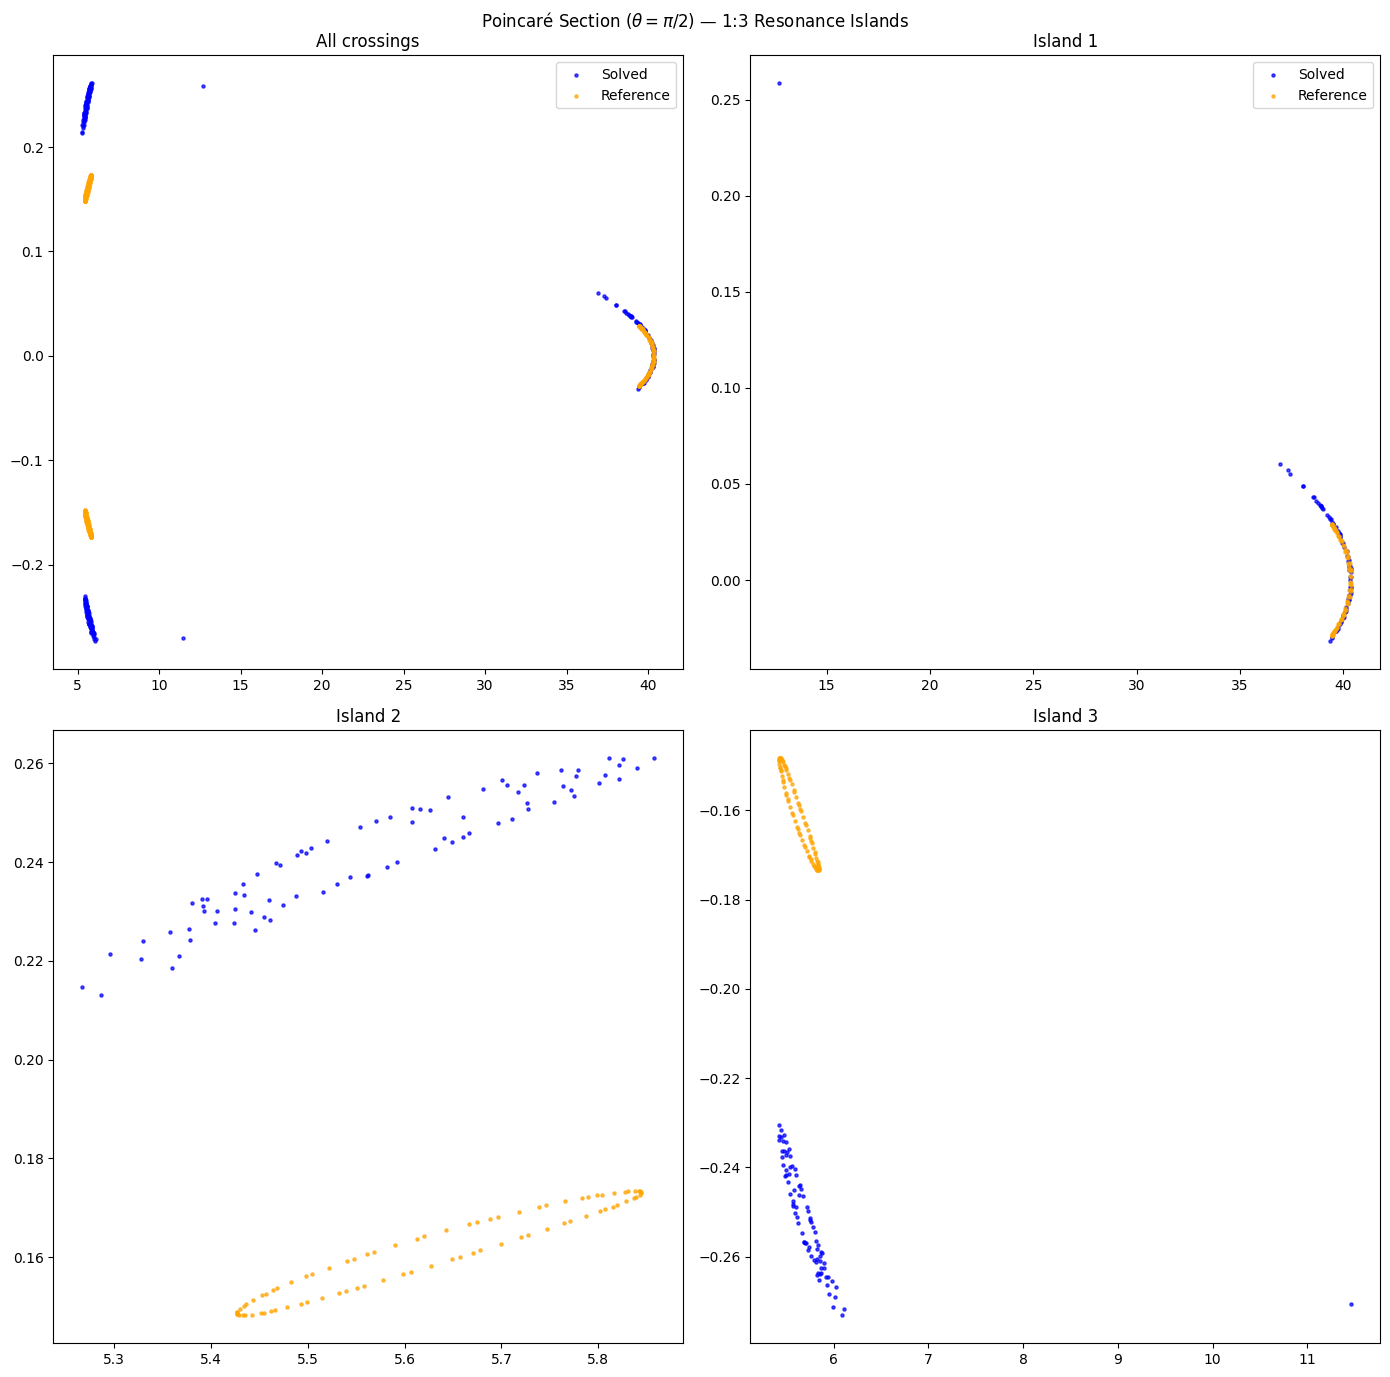

In [13]:
# Poincaré section (theta = pi/2, descending crossings)
def get_precise_crossings(lam_arr, th_arr, r_arr, pr_arr, target_th=np.pi/2):
    mask = np.concatenate(([True], np.diff(lam_arr) > 1e-13))
    t_c, th_c, r_c, pr_c = lam_arr[mask], th_arr[mask], r_arr[mask], pr_arr[mask]
    th_spline = CubicSpline(t_c, th_c)
    r_spline = CubicSpline(t_c, r_c)
    pr_spline = CubicSpline(t_c, pr_c)
    dth_spline = th_spline.derivative()

    p_r, p_pr, p_lam = [], [], []
    for i in range(len(t_c) - 1):
        if (target_th - th_c[i]) * (target_th - th_c[i+1]) < 0:
            lam_cross = brentq(lambda t: target_th - th_spline(t), t_c[i], t_c[i+1])
            if dth_spline(lam_cross) > 0:
                p_r.append(r_spline(lam_cross))
                p_pr.append(pr_spline(lam_cross))
                p_lam.append(lam_cross)
    return np.array(p_r), np.array(p_pr), np.array(p_lam)

p_r, p_pr, p_lam = get_precise_crossings(lam_arr.to_numpy(), th_arr.to_numpy(),
                                          r_arr.to_numpy(), pr_arr.to_numpy())

# Reference Poincaré data, split by resonance island (1:3 resonance -> every 3rd crossing)
data_pcr = np.loadtxt("Poincare_Mino.dat")
mask_ref = data_pcr[:, 0] <= LAM_RANGE[1]
pr_lam_ref, pr_r_ref, pr_pr_ref = data_pcr[mask_ref, 0], data_pcr[mask_ref, 1], data_pcr[mask_ref, 2]

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes[0, 0].scatter(p_r, p_pr, s=5, alpha=0.7, color='blue', label='Solved')
axes[0, 0].scatter(pr_r_ref, pr_pr_ref, s=5, alpha=0.7, color='orange', label='Reference')
axes[0, 0].set_title('All crossings'); axes[0, 0].legend()

for ax, i in zip([axes[0, 1], axes[1, 0], axes[1, 1]], (2, 3, 4)):
    ax.scatter(p_r[i::3], p_pr[i::3], s=5, alpha=0.7, color='blue', label='Solved')
    ax.scatter(pr_r_ref[i::3], pr_pr_ref[i::3], s=5, alpha=0.7, color='orange', label='Reference')
    ax.set_title(f'Island {i-1}')
axes[0, 1].legend()

plt.suptitle(r"Poincaré Section ($\theta=\pi/2$) — 1:3 Resonance Islands")
plt.tight_layout()
plt.savefig('results/poincare_islands.png', dpi=300, bbox_inches="tight")
plt.show()

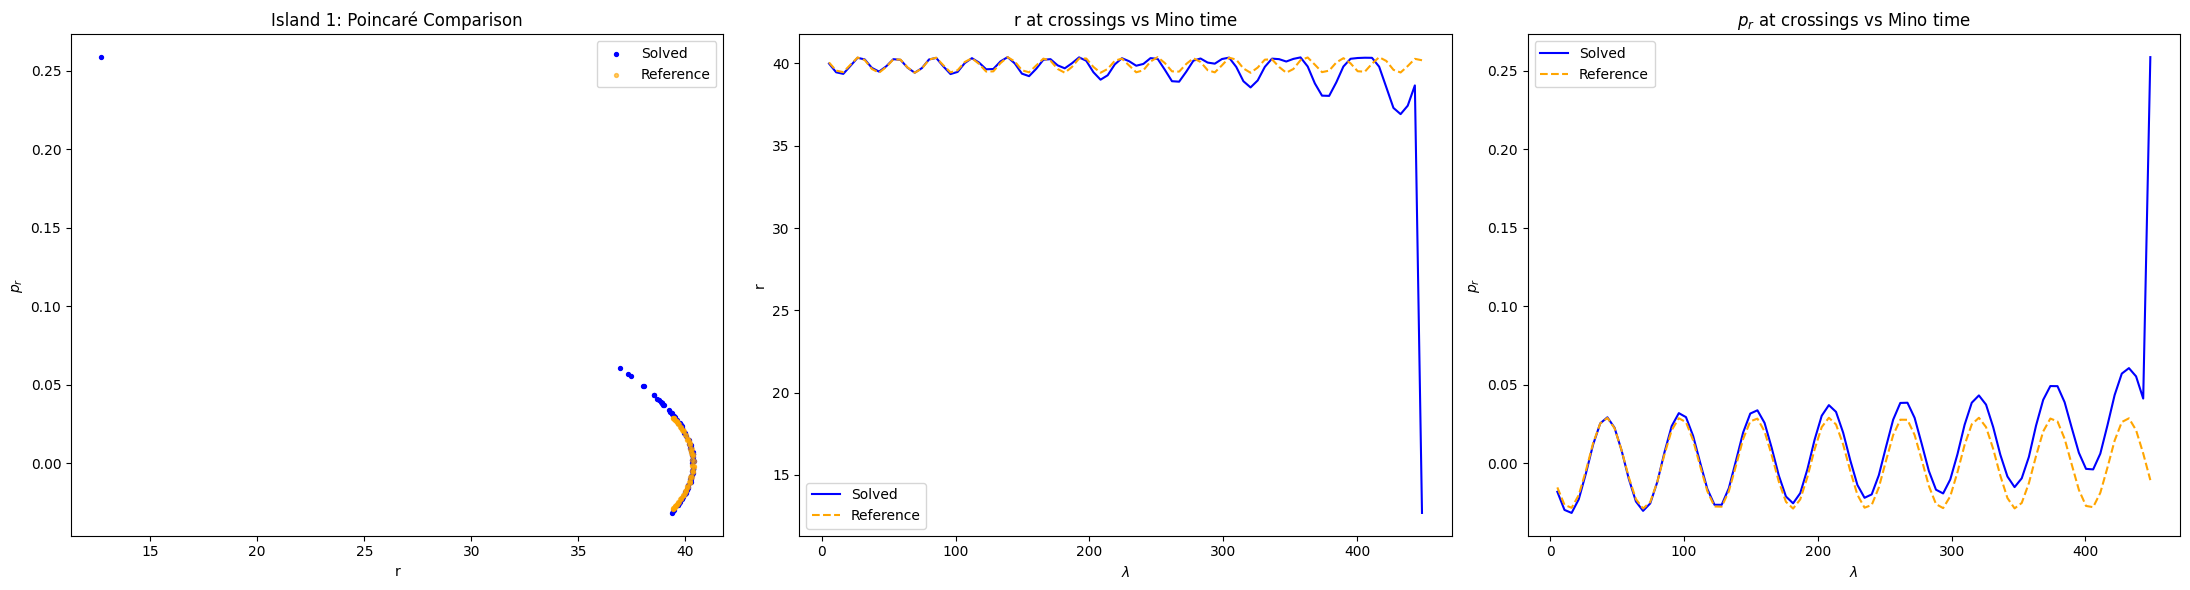

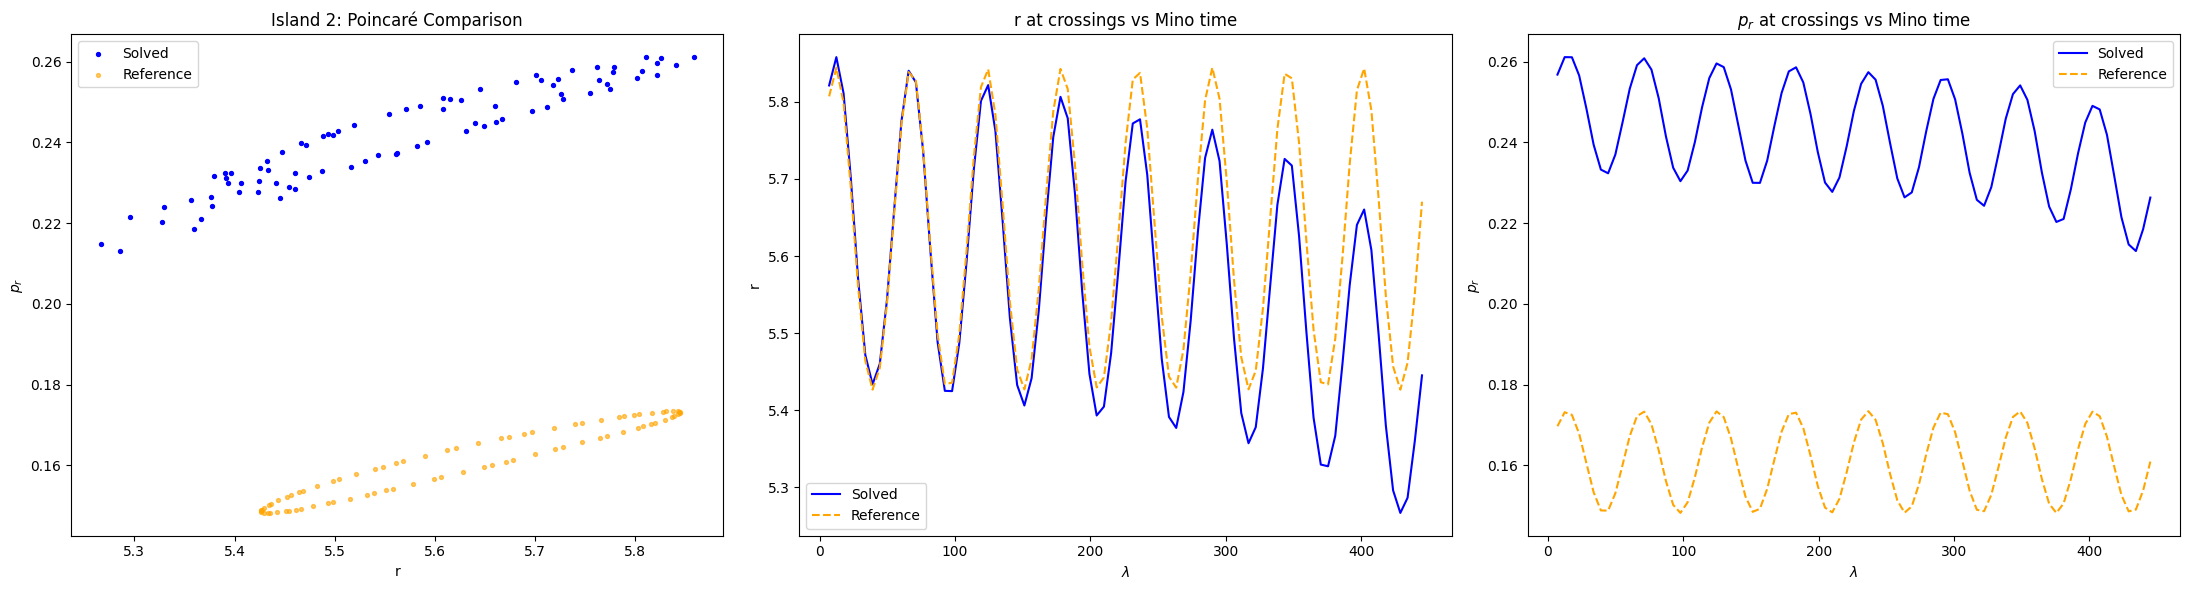

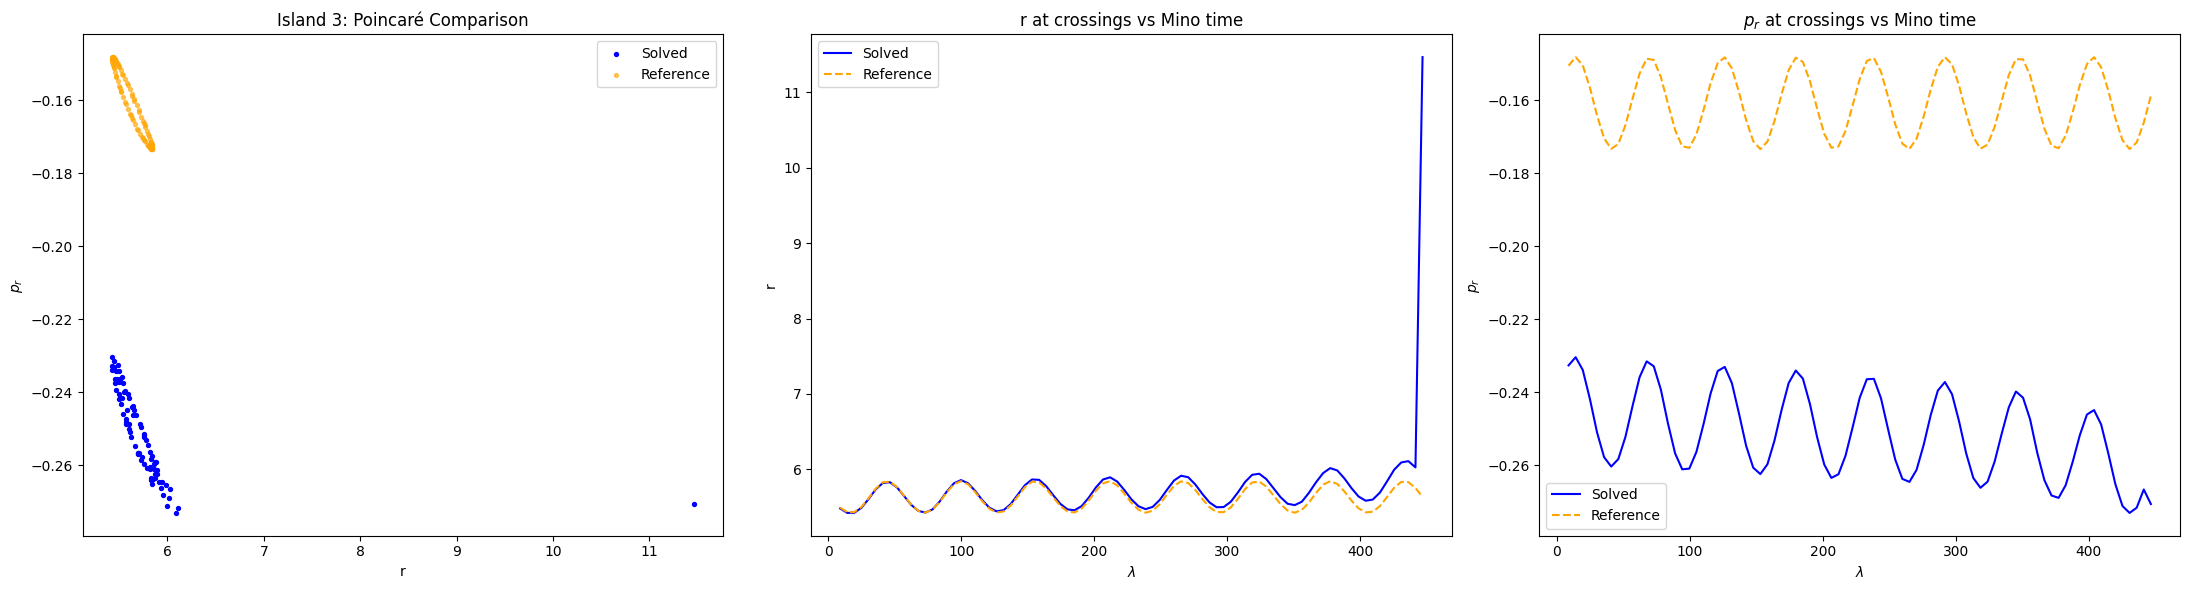

In [14]:
# Crossing values vs Mino time, saved separately for each of the 3 resonance islands
for island_idx in (2, 3, 4):
    island_period = 3

    r_sliced = p_r[island_idx::island_period]
    pr_sliced = p_pr[island_idx::island_period]
    lam_sliced = p_lam[island_idx::island_period]

    r_ref_sliced = pr_r_ref[island_idx::island_period]
    pr_ref_sliced = pr_pr_ref[island_idx::island_period]
    lam_ref_sliced = pr_lam_ref[island_idx::island_period]

    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 6))

    ax1.scatter(r_sliced, pr_sliced, s=8, color='blue', label='Solved')
    ax1.scatter(r_ref_sliced, pr_ref_sliced, s=8, alpha=0.6, color='orange', label='Reference')
    ax1.set_xlabel('r'); ax1.set_ylabel(r'$p_r$')
    ax1.set_title(f'Island {island_idx-1}: Poincaré Comparison')
    ax1.legend()

    ax2.plot(lam_sliced, r_sliced, color='blue', label='Solved')
    ax2.plot(lam_ref_sliced, r_ref_sliced, '--', color='orange', label='Reference')
    ax2.set_xlabel(r'$\lambda$'); ax2.set_ylabel('r')
    ax2.set_title('r at crossings vs Mino time')
    ax2.legend()

    ax3.plot(lam_sliced, pr_sliced, color='blue', label='Solved')
    ax3.plot(lam_ref_sliced, pr_ref_sliced, '--', color='orange', label='Reference')
    ax3.set_xlabel(r'$\lambda$'); ax3.set_ylabel(r'$p_r$')
    ax3.set_title(r'$p_r$ at crossings vs Mino time')
    ax3.legend()

    plt.tight_layout()
    plt.savefig(f'results/poincare_crossing_timeseries_island{island_idx-1}.png',
                dpi=300, bbox_inches="tight")
    plt.show()

## 7. δK-amplification at turning points

Main result: perturbing the Carter constant K(λ) by a small, fixed δK and
re-integrating shows the resulting trajectory divergence grows
exponentially in λ, with amplification concentrated at turning-point
crossings — evidence for the √-amplification mechanism at turning-point
singularities described in the report.

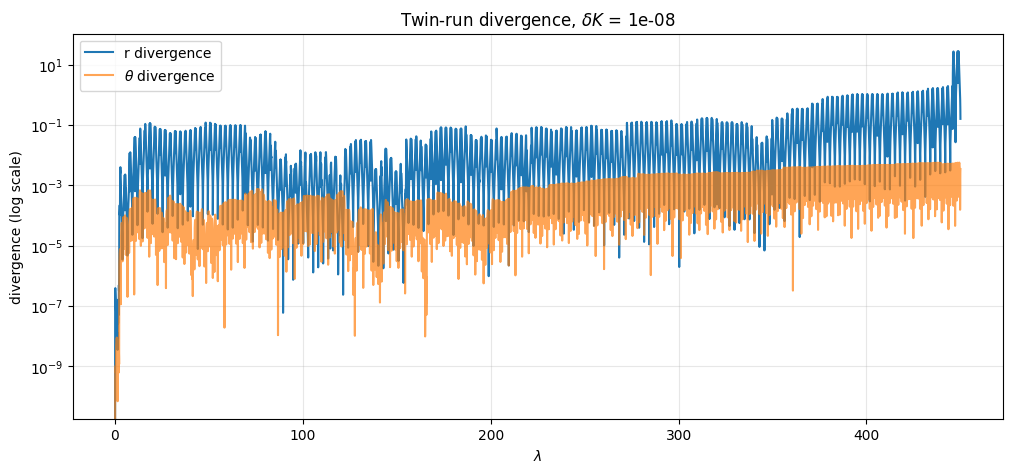

Estimated growth rate: mu = 0.01024 per unit lambda
mu > 0 -> amplifying/unstable to K-errors


In [15]:
# Twin experiment: identical run, K(lambda) offset by a small delta
K_PERTURBATION = 1e-8
get_K_perturbed = lambda lam: get_K(lam) + K_PERTURBATION

results_perturbed = geodesic_integrator(
    init_state, initial_signs=[-1, 1], lam_range=LAM_RANGE,
    params=phys_params, epsilon=eps,
    proxy_eps=PROXY_EPS, proxy_eps_th=PROXY_EPS_TH,
    rtol=RTOL, atol=ATOL, K_func=get_K_perturbed
)

lam_A, r_A, th_A = (clean_run(results)[k] for k in ('lambda', 'r', 'theta'))
lam_B, r_B, th_B = (clean_run(results_perturbed)[k] for k in ('lambda', 'r', 'theta'))

lam_end = min(lam_A[-1], lam_B[-1])
lam_grid_twin = np.linspace(0, lam_end, 10000)
r_A_grid = CubicSpline(lam_A, r_A)(lam_grid_twin)
r_B_grid = CubicSpline(lam_B, r_B)(lam_grid_twin)
th_A_grid = CubicSpline(lam_A, th_A)(lam_grid_twin)
th_B_grid = CubicSpline(lam_B, th_B)(lam_grid_twin)

divergence_r = np.abs(r_B_grid - r_A_grid)
divergence_th = np.abs(th_B_grid - th_A_grid)

plt.figure(figsize=(12, 5))
plt.semilogy(lam_grid_twin, divergence_r, label='r divergence')
plt.semilogy(lam_grid_twin, divergence_th, label=r'$\theta$ divergence', alpha=0.7)
plt.xlabel(r'$\lambda$'); plt.ylabel('divergence (log scale)')
plt.title(rf'Twin-run divergence, $\delta K$ = {K_PERTURBATION:.0e}')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('results/dK_divergence.png', dpi=300, bbox_inches="tight")
plt.show()

# Exponential growth rate: divergence ~ exp(mu * lambda)
floor = 1e-12
mask_fit = divergence_r > floor
if mask_fit.sum() > 10:
    mu, intercept = np.polyfit(lam_grid_twin[mask_fit], np.log(divergence_r[mask_fit]), 1)
    print(f"Estimated growth rate: mu = {mu:.5f} per unit lambda")
    print("mu > 0 -> amplifying/unstable to K-errors" if mu > 0 else "mu <= 0 -> bounded")

In [16]:
# Correlate divergence jumps with turning-point crossings
peak_idx, _ = find_peaks(divergence_r)
peak_lam, peak_val = lam_grid_twin[peak_idx], divergence_r[peak_idx]

event_lams = results['log']['lambda'].values
log_peak = np.log(np.maximum(peak_val, 1e-15))
step_size = np.diff(log_peak)
jump_threshold = 2.0   # natural-log units (~7x jump)
jump_locs = peak_lam[1:][np.abs(step_size) > jump_threshold]


print("Detected jump locations (λ):", jump_locs)
for jl in jump_locs:
    nearest = event_lams[np.argmin(np.abs(event_lams - jl))]
    print(f"  jump at λ≈{jl:.2f} -> nearest turning-point event at λ={nearest:.2f}, "
          f"Δ={abs(jl-nearest):.3f}")

r_at_jump = np.interp(jump_locs, lam_A, r_A)
print("r at jump locations:", r_at_jump)

Detected jump locations (λ): [  2.52025203   2.74527453   7.83078308 101.62016202 104.00540054
 114.53645365 114.62646265 119.08190819 119.9369937  122.59225923
 138.65886589 154.18541854 155.04050405 193.92439244 194.73447345
 446.30963096]
  jump at λ≈2.52 -> nearest turning-point event at λ=2.65, Δ=0.131
  jump at λ≈2.75 -> nearest turning-point event at λ=2.65, Δ=0.094
  jump at λ≈7.83 -> nearest turning-point event at λ=7.96, Δ=0.131
  jump at λ≈101.62 -> nearest turning-point event at λ=101.50, Δ=0.119
  jump at λ≈104.01 -> nearest turning-point event at λ=104.16, Δ=0.155
  jump at λ≈114.54 -> nearest turning-point event at λ=114.34, Δ=0.194
  jump at λ≈114.63 -> nearest turning-point event at λ=114.78, Δ=0.150
  jump at λ≈119.08 -> nearest turning-point event at λ=118.79, Δ=0.297
  jump at λ≈119.94 -> nearest turning-point event at λ=120.09, Δ=0.152
  jump at λ≈122.59 -> nearest turning-point event at λ=122.75, Δ=0.159
  jump at λ≈138.66 -> nearest turning-point event at λ=138.8

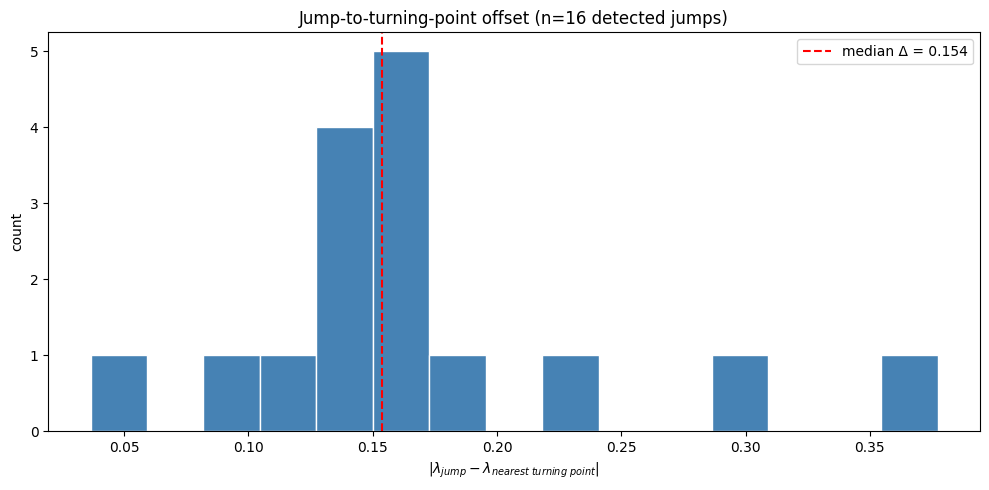

Median offset: 0.154
81% of jumps within 0.2 of a turning-point event


In [17]:
# Direct evidence: how close is each detected jump to its nearest turning point?
deltas = np.array([abs(jl - event_lams[np.argmin(np.abs(event_lams - jl))]) for jl in jump_locs])

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(deltas, bins=15, color='steelblue', edgecolor='white')
ax.axvline(np.median(deltas), color='red', linestyle='--',
           label=f'median Δ = {np.median(deltas):.3f}')
ax.set_xlabel(r'$|\lambda_{jump} - \lambda_{nearest\ turning\ point}|$')
ax.set_ylabel('count')
ax.set_title(f'Jump-to-turning-point offset (n={len(jump_locs)} detected jumps)')
ax.legend()
plt.tight_layout()
plt.savefig('results/jump_turning_point_offset_hist.png', dpi=300, bbox_inches="tight")
plt.show()

print(f"Median offset: {np.median(deltas):.3f}")
print(f"{np.mean(deltas < 0.2)*100:.0f}% of jumps within 0.2 of a turning-point event")

Median spacing between turning points: 0.473
Min spacing: 0.000
Observed mean log-jump at turning points: 0.0142
Null mean (random λ locations):           0.0006 ± 0.0074
Permutation p-value: 0.0324


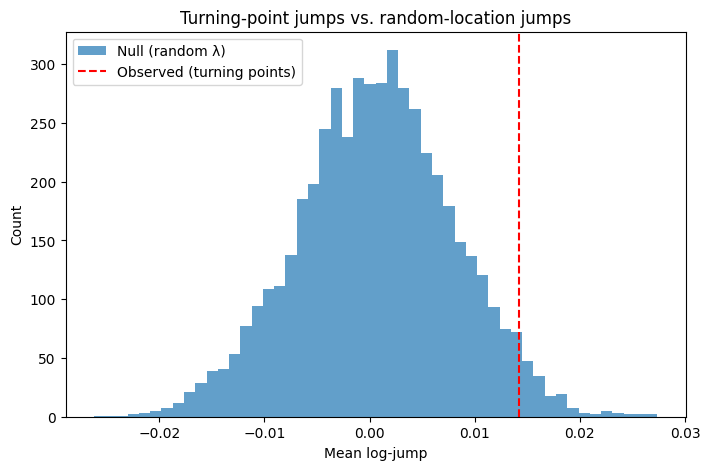

In [18]:
# Permutation test: are divergence jumps larger at turning points than chance?
def local_jump(t_event, lam_grid, divergence, window=0.5):
    before = np.interp(t_event - window, lam_grid, divergence)
    after  = np.interp(t_event + window, lam_grid, divergence)
    # log-ratio, not raw difference — divergence grows exponentially,
    # so this is the right scale to compare jumps on
    return np.log(max(after, 1e-15)) - np.log(max(before, 1e-15))

# Diagnose actual turning-point spacing first
spacings = np.diff(np.sort(event_lams))
print(f"Median spacing between turning points: {np.median(spacings):.3f}")
print(f"Min spacing: {np.min(spacings):.3f}")

window = 0.01
valid_events = event_lams[(event_lams > lam_grid_twin[0] + window) &
                           (event_lams < lam_grid_twin[-1] - window)]
observed_jumps = np.array([local_jump(t, lam_grid_twin, divergence_r, window) for t in valid_events])
observed_mean = observed_jumps.mean()

n_perm = 5000
rng = np.random.default_rng(0)
lam_min, lam_max = lam_grid_twin[0] + window, lam_grid_twin[-1] - window
null_means = np.empty(n_perm)
for i in range(n_perm):
    pseudo_events = rng.uniform(lam_min, lam_max, size=len(valid_events))
    null_means[i] = np.mean([local_jump(t, lam_grid_twin, divergence_r, window) for t in pseudo_events])

p_value = np.mean(null_means >= observed_mean)
print(f"Observed mean log-jump at turning points: {observed_mean:.4f}")
print(f"Null mean (random λ locations):           {null_means.mean():.4f} ± {null_means.std():.4f}")
print(f"Permutation p-value: {p_value:.4f}")

plt.figure(figsize=(8, 5))
plt.hist(null_means, bins=50, alpha=0.7, label='Null (random λ)')
plt.axvline(observed_mean, color='red', linestyle='--', label='Observed (turning points)')
plt.xlabel('Mean log-jump'); plt.ylabel('Count')
plt.legend(); plt.title('Turning-point jumps vs. random-location jumps')
plt.savefig('results/turning_point_permutation_test.png', dpi=300, bbox_inches="tight")
plt.show()

Radial period Λ_r ≈ 2.6703
r: μ = 0.01479/λ,  μ_cycle = 0.0395/orbit,  err0 = 1.527e-04


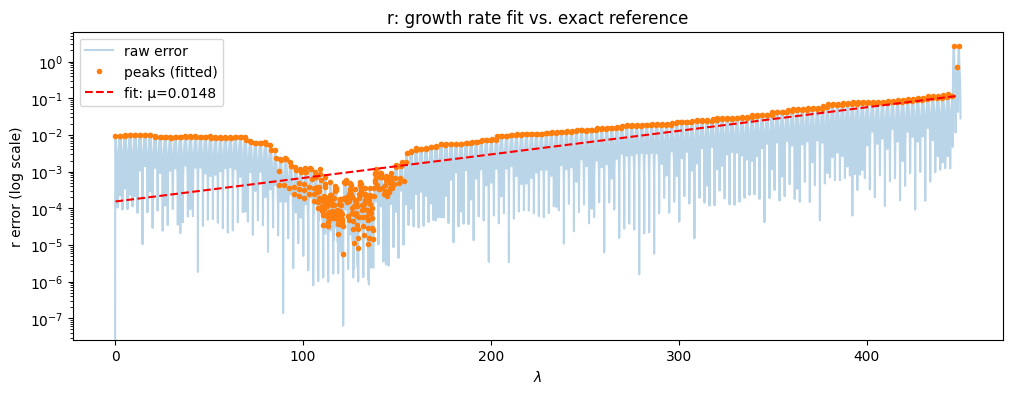

theta: μ = 0.00750/λ,  μ_cycle = 0.0200/orbit,  err0 = 6.704e-04


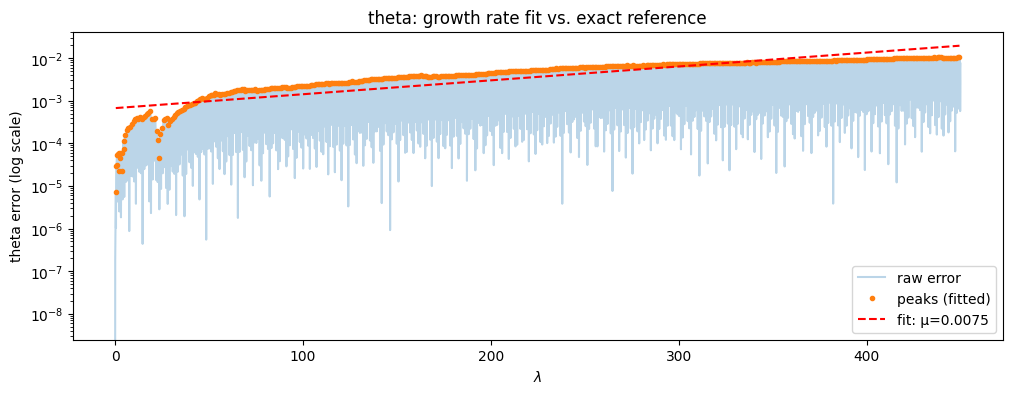

r: 5 jumps, median offset from turning point = 0.366, 20% within 0.2
theta: 0 jumps, median offset from turning point = nan, 0% within 0.2
tol=1e-03: N_max (r) ≈ 47.6 cycles, N_max (theta) ≈ 20.0 cycles
tol=1e-02: N_max (r) ≈ 105.9 cycles, N_max (theta) ≈ 134.9 cycles
tol=1e-01: N_max (r) ≈ 164.2 cycles, N_max (theta) ≈ 249.9 cycles


In [19]:
# --- Growth rate + regimes: integrated (smoothed-K) trajectory vs exact reference ---
# Uses error_r, error_th, lam_grid already computed in the trajectory-comparison cell

# --- Radial period, if not already computed ---
log_df = results['log']
is_radial_event = log_df['events'].apply(lambda e: e[0] > 0)
radial_event_lams = log_df.loc[is_radial_event, 'lambda'].values
half_periods = np.diff(radial_event_lams)
Lambda_r = 2 * np.median(half_periods)
print(f"Radial period Λ_r ≈ {Lambda_r:.4f}")

# --- Growth rate fit on the peak envelope, r and theta separately ---
def fit_growth_rate(lam_grid, error_arr, label):
    peak_idx, _ = find_peaks(error_arr)
    peak_lam, peak_val = lam_grid[peak_idx], error_arr[peak_idx]
    mask = peak_val > 1e-15
    mu, log_err0 = np.polyfit(peak_lam[mask], np.log(peak_val[mask]), 1)
    err0 = np.exp(log_err0)
    print(f"{label}: μ = {mu:.5f}/λ,  μ_cycle = {mu*Lambda_r:.4f}/orbit,  err0 = {err0:.3e}")

    plt.figure(figsize=(12, 4))
    plt.semilogy(lam_grid, error_arr, alpha=0.3, label='raw error')
    plt.semilogy(peak_lam, peak_val, 'o', ms=3, label='peaks (fitted)')
    plt.semilogy(peak_lam, np.exp(mu*peak_lam + log_err0), 'r--', label=f'fit: μ={mu:.4f}')
    plt.xlabel(r'$\lambda$'); plt.ylabel(f'{label} error (log scale)')
    plt.legend(); plt.title(f'{label}: growth rate fit vs. exact reference')
    plt.savefig(f'results/reference_error_growth_{label}.png', dpi=300, bbox_inches="tight")
    plt.show()

    return mu, err0, peak_lam, peak_val

mu_r, err0_r, peak_lam_r, peak_val_r = fit_growth_rate(lam_grid, error_r, 'r')
mu_th, err0_th, peak_lam_th, peak_val_th = fit_growth_rate(lam_grid, error_th, 'theta')

# --- Regime check: are error jumps localized at turning points? ---
event_lams = results['log']['lambda'].values

def regime_check(peak_lam, peak_val, event_lams, label, jump_threshold=2.0):
    log_peak = np.log(np.maximum(peak_val, 1e-15))
    step_size = np.diff(log_peak)
    jump_locs = peak_lam[1:][np.abs(step_size) > jump_threshold]
    deltas = np.array([abs(jl - event_lams[np.argmin(np.abs(event_lams - jl))]) for jl in jump_locs])
    print(f"{label}: {len(jump_locs)} jumps, median offset from turning point = "
          f"{np.median(deltas) if len(deltas) else float('nan'):.3f}, "
          f"{np.mean(deltas < 0.2)*100 if len(deltas) else 0:.0f}% within 0.2")
    return jump_locs, deltas

jump_locs_r, deltas_r = regime_check(peak_lam_r, peak_val_r, event_lams, 'r')
jump_locs_th, deltas_th = regime_check(peak_lam_th, peak_val_th, event_lams, 'theta')

# --- Cycles-before-tolerance estimate ---
def max_cycles_before_tolerance(tol, err0, mu, Lambda_r):
    if mu <= 0:
        return np.inf
    lam_max = np.log(tol / err0) / mu
    return lam_max / Lambda_r

for tol in [1e-3, 1e-2, 1e-1]:
    N_r = max_cycles_before_tolerance(tol, err0_r, mu_r, Lambda_r)
    N_th = max_cycles_before_tolerance(tol, err0_th, mu_th, Lambda_r)
    print(f"tol={tol:.0e}: N_max (r) ≈ {N_r:.1f} cycles, N_max (theta) ≈ {N_th:.1f} cycles")

In [20]:
# Calculate partial derivatives for V1_full
dV1_dr = sp.diff(V1_full, r)
dV1_dtheta = sp.diff(V1_full, theta)
dV1_dkappa = sp.diff(V1_full, kappa)

# Calculate partial derivatives for V2_full
dV2_dr = sp.diff(V2_full, r)
dV2_dtheta = sp.diff(V2_full, theta)
dV2_dkappa = sp.diff(V2_full, kappa)

# Group the results for display
derivatives = [
    (r"\frac{\partial V_1}{\partial r}", dV1_dr),
    (r"\frac{\partial V_1}{\partial \theta}", dV1_dtheta),
    (r"\frac{\partial V_1}{\partial \kappa}", dV1_dkappa),
    (r"\frac{\partial V_2}{\partial r}", dV2_dr),
    (r"\frac{\partial V_2}{\partial \theta}", dV2_dtheta),
    (r"\frac{\partial V_2}{\partial \kappa}", dV2_dkappa)
]

# Display as a single, center-aligned block with aligned equals signs
latex_str = "### Partial Derivatives\n$$\n\\Large\n\\begin{aligned}\n"

lines = []
for label, expr in derivatives:
    # Note: .simplify() can be slow on the fully substituted expressions. 
    # Remove it if the cell takes too long to run.
    lines.append(f"{label} &= {sp.latex(expr.simplify())}")
    
# Join the equations with a newline and a little extra vertical spacing
latex_str += " \\\\[2ex]\n".join(lines)
latex_str += "\n\\end{aligned}\n$$"

display(Markdown(latex_str))

### Partial Derivatives
$$
\Large
\begin{aligned}
\frac{\partial V_1}{\partial r} &= \frac{- 2 \epsilon^{2} r^{3} \left(a^{2} + r^{2} - 2.0 r\right) \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) + \epsilon^{2} r^{2} \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(\left(2 r - 2.0\right) \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) + \left(a^{2} + r^{2} - 2.0 r\right) \left(a^{2} \left(2 r - 2.0\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(8 r - 8.0\right) + \left(- 4 a^{2} r + 8.0 a^{2} - 4 r^{3}\right) \sin^{2}{\left(\theta \right)}\right)\right) + 2 \epsilon^{2} r \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(a^{2} + r^{2} - 2.0 r\right) \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) + 4 \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right)^{2} \left(4 E r \left(E \left(a^{2} + r^{2}\right) - L_{z} a\right) - \epsilon r^{2} \left(2 r - 2.0\right) \left(2 E a - L_{z}\right) - 2 \epsilon r \left(2 E a - L_{z}\right) \left(a^{2} + r^{2} - 2.0 r\right) - 2 r \left(a^{2} + r^{2} - 2.0 r\right) - \left(\kappa + r^{2}\right) \left(2 r - 2.0\right)\right)}{4 \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right)^{2}} \\[2ex]
\frac{\partial V_1}{\partial \theta} &= \frac{\epsilon^{2} r^{2} \left(a^{2} \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) + \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r + 2 a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{2}{\left(\theta \right)} - r^{4}\right)\right) \left(a^{2} + r^{2} - 2.0 r\right) \sin{\left(\theta \right)} \cos{\left(\theta \right)}}{2 \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right)^{2}} \\[2ex]
\frac{\partial V_1}{\partial \kappa} &= - a^{2} - r^{2} + 2.0 r \\[2ex]
\frac{\partial V_2}{\partial r} &= \frac{a^{2} \epsilon^{2} \left(- 4 r \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) + \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(a^{2} \left(4 r - 4.0\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(16 r - 16.0\right) + \left(- 8 a^{2} r + 16.0 a^{2} - 8 r^{3}\right) \sin^{2}{\left(\theta \right)}\right)\right) \cos^{2}{\left(\theta \right)}}{8 \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right)^{2}} \\[2ex]
\frac{\partial V_2}{\partial \theta} &= \frac{\left(- \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(a^{2} \epsilon^{2} \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} + 4 \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(\frac{E^{2} a^{2} \left(1 - \cos{\left(4 \theta \right)}\right)}{8} - L_{z}^{2} \cos^{2}{\left(\theta \right)} + \frac{a^{2} \epsilon \left(1 - \cos{\left(4 \theta \right)}\right) \left(2 E a - L_{z}\right)}{8} - \frac{a^{2} \left(1 - \cos{\left(4 \theta \right)}\right)}{8} + \left(\kappa - \left(E a - L_{z}\right)^{2}\right) \sin^{2}{\left(\theta \right)}\right)\right) + \left(a^{4} \epsilon^{2} \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} + a^{2} \epsilon^{2} \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{4}{\left(\theta \right)} + a^{2} \left(4 a^{2} + 4 r^{2} - 8.0 r\right) + \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r - r^{4}\right) \sin^{2}{\left(\theta \right)}\right) \cos{\left(2 \theta \right)} + a^{2} \epsilon^{2} \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right) \left(- 5 a^{4} - 2 a^{2} r^{2} + 8.0 a^{2} r + 2 a^{2} \left(a^{2} + r^{2} - 2.0 r\right) \sin^{2}{\left(\theta \right)} - r^{4}\right) \sin^{2}{\left(\theta \right)} \cos^{2}{\left(\theta \right)} + 4 \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right)^{2} \left(- 2 E^{2} a^{2} \sin^{2}{\left(\theta \right)} + 2 E L_{z} a - 4 E a^{3} \epsilon \sin^{2}{\left(\theta \right)} + 2 E a^{3} \epsilon + 2 L_{z} a^{2} \epsilon \sin^{2}{\left(\theta \right)} - L_{z} a^{2} \epsilon + 2 a^{2} \sin^{2}{\left(\theta \right)} - a^{2} + \kappa\right)\right) \sin^{2}{\left(\theta \right)}\right) \cos{\left(\theta \right)}}{2 \left(a^{2} \cos^{2}{\left(\theta \right)} + r^{2}\right)^{2} \sin^{3}{\left(\theta \right)}} \\[2ex]
\frac{\partial V_2}{\partial \kappa} &= 1
\end{aligned}
$$

In [21]:
# Group the variables to match your existing lambdify signature
args = (r, theta, E, Lz, a, kappa, epsilon)

# Create dictionaries for V1 and V2 derivatives
partial_V1 = {
    'r': sp.lambdify(args, dV1_dr, 'numpy'),
    'theta': sp.lambdify(args, dV1_dtheta, 'numpy'),
    'kappa': sp.lambdify(args, dV1_dkappa, 'numpy')
}

partial_V2 = {
    'r': sp.lambdify(args, dV2_dr, 'numpy'),
    'theta': sp.lambdify(args, dV2_dtheta, 'numpy'),
    'kappa': sp.lambdify(args, dV2_dkappa, 'numpy')
}

In [22]:
# 1. Your original starting parameters
r0, th0 = 40.323, np.pi/2
E_val, Lz_val, a_val = 0.98, 3.3, 0.5
eps = -0.001
lam_start = 0

# 2. Get the initial Carter constant
k0 = get_K(lam_start)

# 3. Evaluate the initial potentials
V1_0, V2_0 = rhs_potentials(r0, th0, E_val, Lz_val, a_val, k0, eps)

# 4. Calculate initial kinematic velocities (applying your [-1, 1] signs)
vr_0 = -1 * np.sqrt(V1_0)
vth_0 = 1 * np.sqrt(V2_0)

# The final array to pass to the function
init_state = [r0, th0, vr_0, vth_0]

print(init_state)

[40.323, 1.5707963267948966, np.float64(-1.613872731670287), np.float64(1.2708136747859435)]


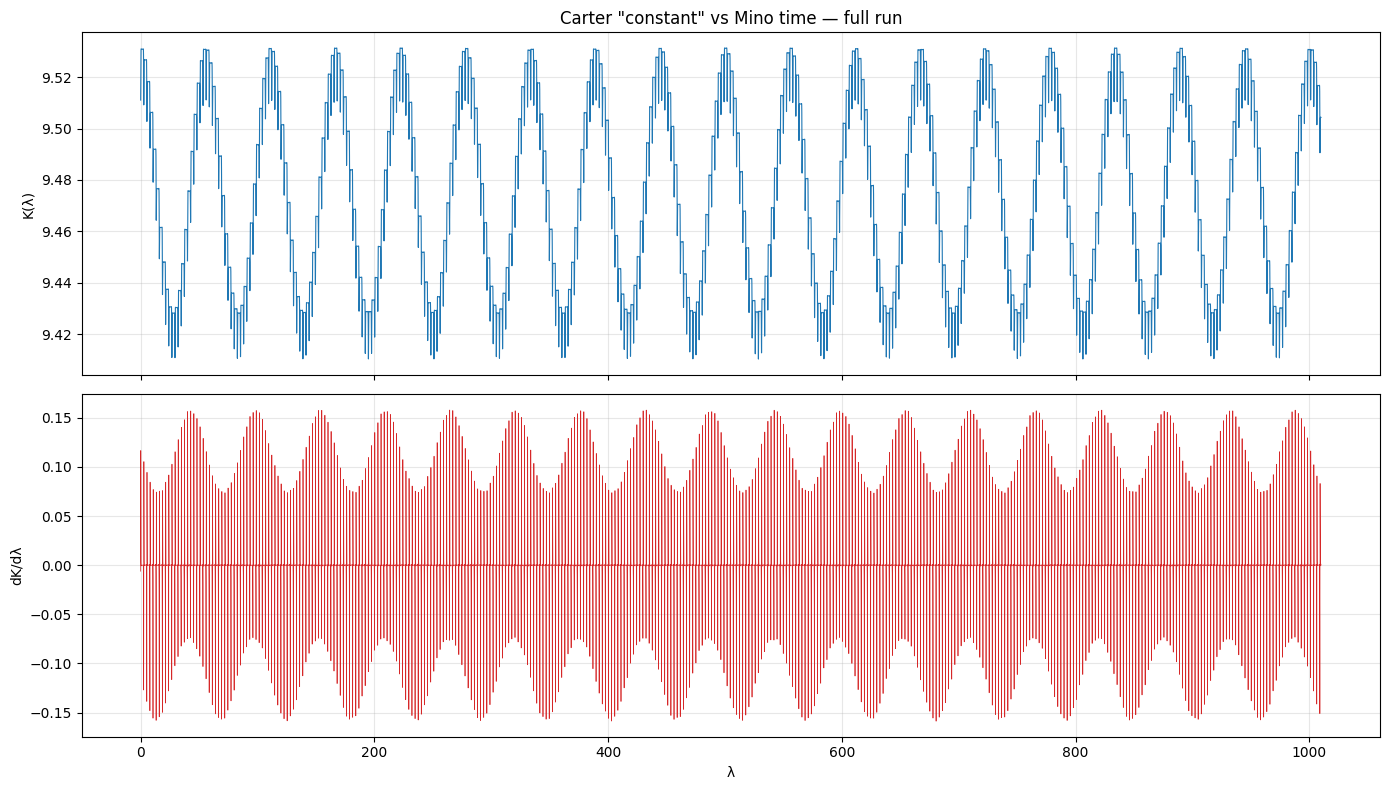

K range: [9.410338, 9.531364]  (span 1.210e-01)
Kdot range: [-1.588e-01, 1.580e-01]  |mean|=1.476e-02
Secular linear-fit slope: 2.136e-06/λ  -> drift over full run ≈ 2.157e-03


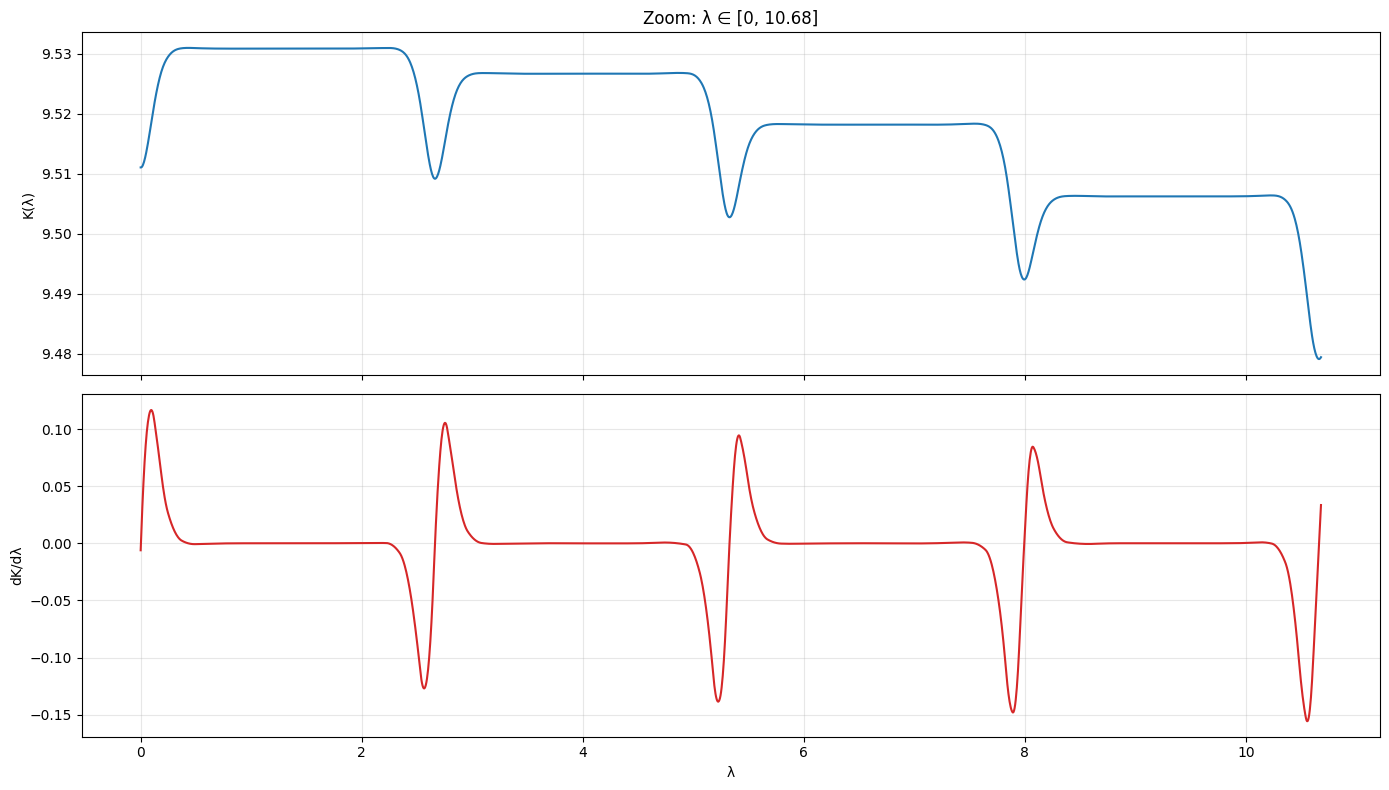

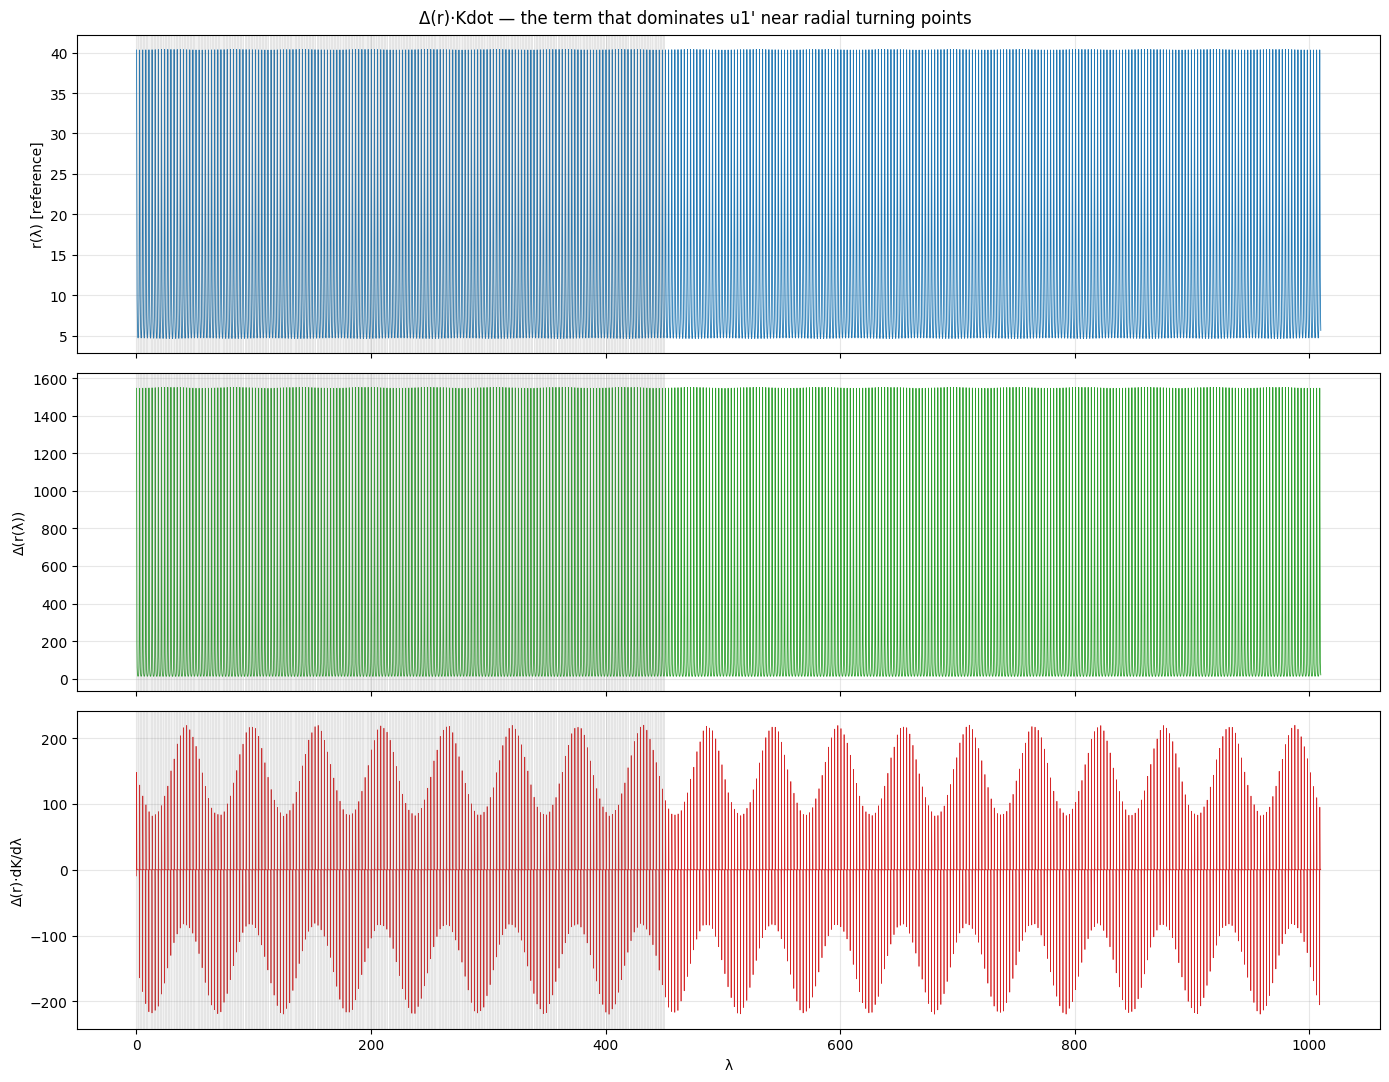

Δ(r) range: [12.38, 1550.81]
Δ·Kdot range: [-2.197e+02, 2.197e+02], |mean|=1.524e+01
|Δ·Kdot| at events:  mean=1.696e+01, median=7.094e-03
|Δ·Kdot| at random λ: mean=1.569e+01, median=9.846e-03
ratio (event/random): 1.08x


In [23]:
import numpy as np
from scipy.signal import savgol_filter
from scipy.interpolate import UnivariateSpline, CubicSpline
import matplotlib.pyplot as plt

# ---- 1. Reuse or (re)build get_K ----
if 'lam_data_carter' not in dir():
    data_carter = np.loadtxt('DATA_CARTER.dat')
    lam_data_carter = data_carter[:, 0]
    k_values = data_carter[:, 1]

if 'get_K' not in dir():
    def make_smooth_K(lam_data, k_values, window=51, poly=3, spline_smooth=1e-4):
        window = window if window % 2 == 1 else window + 1
        k_sg = savgol_filter(k_values, window_length=window, polyorder=poly)
        return UnivariateSpline(lam_data, k_sg, s=spline_smooth, ext='const')
    get_K = make_smooth_K(lam_data_carter, k_values)

get_Kdot = get_K.derivative()   # analytic derivative of the smoothed spline — cleaner than finite-differencing 1e6 raw points

# ---- 2. K(λ) and Kdot(λ), full run ----
lam_grid = np.linspace(lam_data_carter[0], lam_data_carter[-1], 200_000)
K_grid, Kdot_grid = get_K(lam_grid), get_Kdot(lam_grid)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(lam_grid, K_grid, lw=0.8); axes[0].set_ylabel('K(λ)')
axes[0].set_title('Carter "constant" vs Mino time — full run'); axes[0].grid(alpha=0.3)
axes[1].plot(lam_grid, Kdot_grid, lw=0.5, color='tab:red'); axes[1].set_ylabel('dK/dλ')
axes[1].set_xlabel('λ'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"K range: [{K_grid.min():.6f}, {K_grid.max():.6f}]  (span {K_grid.max()-K_grid.min():.3e})")
print(f"Kdot range: [{Kdot_grid.min():.3e}, {Kdot_grid.max():.3e}]  |mean|={np.mean(np.abs(Kdot_grid)):.3e}")

slope, _ = np.polyfit(lam_grid, K_grid, 1)
print(f"Secular linear-fit slope: {slope:.3e}/λ  -> drift over full run ≈ {slope*lam_grid[-1]:.3e}")

# ---- 3. Zoom: first ~4 radial periods (Λ_r ≈ 2.6703) ----
zoom_max = 4 * 2.6703
m = lam_grid <= zoom_max
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(lam_grid[m], K_grid[m]); axes[0].set_ylabel('K(λ)')
axes[0].set_title(f'Zoom: λ ∈ [0, {zoom_max:.2f}]'); axes[0].grid(alpha=0.3)
axes[1].plot(lam_grid[m], Kdot_grid[m], color='tab:red'); axes[1].set_ylabel('dK/dλ')
axes[1].set_xlabel('λ'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- 4. Δ(r(λ)) along the true reference trajectory, and Δ·Kdot ----
M_val = 1.0
try:
    a_val_local = a_val
except NameError:
    a_val_local = 0.5

data_r_ext = np.loadtxt('reference_r.dat')
lam_ref, r_ref = data_r_ext[:, 0], data_r_ext[:, 1]

lam_c = np.linspace(max(lam_data_carter[0], lam_ref[0]),
                     min(lam_data_carter[-1], lam_ref[-1]), 200_000)
r_c = CubicSpline(lam_ref, r_ref)(lam_c)
Kdot_c = get_Kdot(lam_c)
Delta_c = r_c**2 - 2*M_val*r_c + a_val_local**2
DeltaKdot_c = Delta_c * Kdot_c          # exact term appearing in u1'

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
axes[0].plot(lam_c, r_c, lw=0.6); axes[0].set_ylabel('r(λ) [reference]'); axes[0].grid(alpha=0.3)
axes[1].plot(lam_c, Delta_c, lw=0.6, color='tab:green'); axes[1].set_ylabel('Δ(r(λ))'); axes[1].grid(alpha=0.3)
axes[2].plot(lam_c, DeltaKdot_c, lw=0.5, color='tab:red'); axes[2].set_ylabel('Δ(r)·dK/dλ')
axes[2].set_xlabel('λ'); axes[2].grid(alpha=0.3)

try:
    event_lams = results['log']['lambda'].values
    ev = event_lams[(event_lams >= lam_c[0]) & (event_lams <= lam_c[-1])]
    for ax in axes:
        for e in ev:
            ax.axvline(e, color='gray', alpha=0.15, lw=0.5)
except NameError:
    pass

plt.suptitle("Δ(r)·Kdot — the term that dominates u1' near radial turning points")
plt.tight_layout(); plt.show()

print(f"Δ(r) range: [{Delta_c.min():.2f}, {Delta_c.max():.2f}]")
print(f"Δ·Kdot range: [{DeltaKdot_c.min():.3e}, {DeltaKdot_c.max():.3e}], |mean|={np.mean(np.abs(DeltaKdot_c)):.3e}")

# ---- 5. Is |Δ·Kdot| systematically bigger AT turning-point events than elsewhere? ----
try:
    idx_ev = np.clip(np.searchsorted(lam_c, ev), 0, len(lam_c)-1)
    val_ev = np.abs(DeltaKdot_c[idx_ev])

    rng = np.random.default_rng(0)
    rand_lams = rng.uniform(lam_c[0], lam_c[-1], size=len(ev))
    idx_rand = np.clip(np.searchsorted(lam_c, rand_lams), 0, len(lam_c)-1)
    val_rand = np.abs(DeltaKdot_c[idx_rand])

    print(f"|Δ·Kdot| at events:  mean={val_ev.mean():.3e}, median={np.median(val_ev):.3e}")
    print(f"|Δ·Kdot| at random λ: mean={val_rand.mean():.3e}, median={np.median(val_rand):.3e}")
    print(f"ratio (event/random): {val_ev.mean()/val_rand.mean():.2f}x")
except NameError:
    print("`results` not in memory — run the production integration first for the event-correlation check.")